In [5]:
# IMDB Sentiment Analysis - Improved MLP
# Assignment 2
# Student full name & ID: Oumaima Rtal, 140639
# Date: 15/02/2026
# Course & section: CSC 3348 01
# Overview: this notebook will provide an improved version by building and evaluating multiple models

# let's see what our text looks like before doing anything
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn torch nltk textblob
import pandas as pd

# loading the data
df = pd.read_csv('../IMDB Dataset.csv')

# looking at one review to understand what m I dealing with
print("Original review:")
print(df['review'][0])
print("\n" + "="*50)

     -------------------------------------- 11.3/11.3 MB 354.5 kB/s eta 0:00:00
     -------------------------------------- 12.9/12.9 MB 767.9 kB/s eta 0:00:00
     ---------------------------------------- 8.1/8.1 MB 860.2 kB/s eta 0:00:00
     -------------------------------------- 294.9/294.9 kB 1.8 MB/s eta 0:00:00
     ---------------------------------------- 8.9/8.9 MB 1.4 MB/s eta 0:00:00
     -------------------------------------- 113.7/113.7 MB 1.0 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 751.6 kB/s eta 0:00:00
     -------------------------------------- 624.3/624.3 kB 1.4 MB/s eta 0:00:00
     -------------------------------------- 510.5/510.5 kB 1.9 MB/s eta 0:00:00
     -------------------------------------- 348.5/348.5 kB 2.0 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 2.4 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 1.6/1.6 MB 1.9 MB/s e

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [6]:
# from the earlier step, I have noticed that the reviews contain HTML tags, mixed cases, and some extra spaces so let's look at that
# This is the start of the preprocessing
# I will convert to lower case, remove HTML tags, and remove multiple spaces

import re

def clean_review(text):
    # converting to lowercase
    text = text.lower()
    
    # replacing HTML br tags with a space
    text = re.sub(r'<br\s*/?>', ' ', text)
    
    # removing any other HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # replacing multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    
    # striping leading/trailing spaces
    text = text.strip()
    
    return text

# creating a new cleaned column
df['cleaned_review'] = df['review'].apply(clean_review)

# Check the result
print("Original vs Cleaned:")
print("ORIGINAL:", df['review'][0][:200] + "...")
print("\nCLEANED:", df['cleaned_review'][0][:200] + "...")

Original vs Cleaned:
ORIGINAL: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

CLEANED: one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was i...


In [7]:
# checking a few more reviews
print("Review 1:")
print(df['cleaned_review'][1][:200])
print("\nReview 2:")
print(df['cleaned_review'][2][:200])
print("\nReview 5000:")
print(df['cleaned_review'][5000][:200])

Review 1:
a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. the actors

Review 2:
i thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. the plot is simplistic, but the dialogue is wi

Review 5000:
not a movie for everyone, but this movie is in my top 10. i am a lover of black comedy. with a cast including richard dreyfus (vic), jeff goldblum (mick), larry bishop (nick) and gabriel byrne (ben 'b


In [8]:
# this is the start of the feature engineering
!pip install nltk textblob


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [9]:
# I will install VADER and import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

nltk.download('vader_lexicon')

print("Setup complete! VADER and TextBlob are ready to use.")

Setup complete! VADER and TextBlob are ready to use.


[nltk_data] Error loading vader_lexicon: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


In [10]:
# I will first test VADER and TextBlob on simple sentences to understand better how they work

# initializing VADER
vader = SentimentIntensityAnalyzer()

# testing sentences
test_sentences = [
    "I loved this movie! It was amazing.",
    "This film was terrible. I hated it.",
    "It was okay, nothing special.",
    "The acting was good but the plot was boring."
]

print("="*60)
print("TESTING SENTIMENT ANALYZERS")
print("="*60)

for sentence in test_sentences:
    # getting VADER score
    vader_score = vader.polarity_scores(sentence)['compound']
    
    # getting TextBlob score
    blob = TextBlob(sentence)
    textblob_score = blob.sentiment.polarity
    
    print(f"\nSentence: {sentence}")
    print(f"VADER score (-1 to 1): {vader_score:.3f}")
    print(f"TextBlob score (-1 to 1): {textblob_score:.3f}")
    print(f"Average (hybrid): {(vader_score + textblob_score)/2:.3f}")
    print("-"*40)

TESTING SENTIMENT ANALYZERS

Sentence: I loved this movie! It was amazing.
VADER score (-1 to 1): 0.840
TextBlob score (-1 to 1): 0.738
Average (hybrid): 0.789
----------------------------------------

Sentence: This film was terrible. I hated it.
VADER score (-1 to 1): -0.807
TextBlob score (-1 to 1): -0.950
Average (hybrid): -0.879
----------------------------------------

Sentence: It was okay, nothing special.
VADER score (-1 to 1): -0.092
TextBlob score (-1 to 1): 0.429
Average (hybrid): 0.168
----------------------------------------

Sentence: The acting was good but the plot was boring.
VADER score (-1 to 1): -0.250
TextBlob score (-1 to 1): -0.100
Average (hybrid): -0.175
----------------------------------------


In [11]:
# now let's apply to the entire dataset
# this step will create new columns with sentiment scores

print("Calculating VADER scores for all reviews...")
df['vader_score'] = df['cleaned_review'].apply(lambda x: vader.polarity_scores(x)['compound'])

print("Calculating TextBlob scores for all reviews...")
df['textblob_score'] = df['cleaned_review'].apply(lambda x: TextBlob(x).sentiment.polarity)

# creating a hybrid score (average)
df['hybrid_score'] = (df['vader_score'] + df['textblob_score']) / 2

# let's look at the first 5 rows to see what does things look like now
print("\n" + "="*60)
print("FIRST 5 REVIEWS WITH THEIR SCORES")
print("="*60)
print(df[['cleaned_review', 'vader_score', 'textblob_score', 'hybrid_score']].head())

Calculating VADER scores for all reviews...
Calculating TextBlob scores for all reviews...

FIRST 5 REVIEWS WITH THEIR SCORES
                                      cleaned_review  vader_score  \
0  one of the other reviewers has mentioned that ...      -0.9947   
1  a wonderful little production. the filming tec...       0.9641   
2  i thought this was a wonderful way to spend ti...       0.9780   
3  basically there's a family where a little boy ...      -0.8996   
4  petter mattei's "love in the time of money" is...       0.9803   

   textblob_score  hybrid_score  
0        0.023433     -0.485633  
1        0.109722      0.536911  
2        0.360960      0.669480  
3        0.004167     -0.447717  
4        0.214483      0.597392  


In [12]:
# this is the start of the label encoding
# converting sentiment to binary numbers
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

print("Original sentiment vs numeric label:")
print(df[['sentiment', 'label']].head(10))

print(f"\nLabel distribution:")
print(df['label'].value_counts())

Original sentiment vs numeric label:
  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
5  positive      1
6  positive      1
7  negative      0
8  negative      0
9  positive      1

Label distribution:
label
1    25000
0    25000
Name: count, dtype: int64


In [20]:
# since the features are already on the same scale, I will skip the feature scaling
# this is the train/validation/test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# let's start by all features
# THIS IS THE FIRST CHANGE: Adding two new features
df['review_length'] = df['cleaned_review'].apply(len)
df['word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))

features = ['vader_score', 'textblob_score', 'hybrid_score', 'review_length', 'word_count']

X = df[features]  # features (input)

scaler = StandardScaler()
X[['review_length', 'word_count']] = scaler.fit_transform(X[['review_length', 'word_count']])
y = df['label']   # target (what we want to predict)

# first split: separate training + validation from test (80% - 20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# second split: separate training from validation (75% - 25% of temp = 60% - 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Training set size: {len(X_train)} reviews")
print(f"Validation set size: {len(X_val)} reviews")
print(f"Test set size: {len(X_test)} reviews")
print(f"\nTotal: {len(X_train) + len(X_val) + len(X_test)} reviews")

# let's verify the split preserved the 50-50 balance
print(f"\nTraining set - Positive: {sum(y_train)}, Negative: {len(y_train)-sum(y_train)}")
print(f"Validation set - Positive: {sum(y_val)}, Negative: {len(y_val)-sum(y_val)}")
print(f"Test set - Positive: {sum(y_test)}, Negative: {len(y_test)-sum(y_test)}")

Training set size: 30000 reviews
Validation set size: 10000 reviews
Test set size: 10000 reviews

Total: 50000 reviews

Training set - Positive: 15000, Negative: 15000
Validation set - Positive: 5000, Negative: 5000
Test set - Positive: 5000, Negative: 5000


C:\Users\HP\AppData\Local\Temp\ipykernel_15088\2204913224.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['review_length', 'word_count']] = scaler.fit_transform(X[['review_length', 'word_count']])


In [21]:
# this is the start of building the MLP model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# converting the data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_val_tensor = torch.FloatTensor(X_val.values)
y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# creating data loaders (for batching)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [22]:
class SentimentMLP(nn.Module):
    """
    Architecture:
    - Input layer: 5 features (vader, textblob, hybrid, length, word_count)
    - Hidden layer 1: 32 neurons with ReLU
    - Hidden layer 2: 16 neurons with ReLU
    - Output layer: 1 neuron with Sigmoid
    """
    
    def __init__(self, input_size=3, hidden_size1=16, hidden_size2=8):
        super(SentimentMLP, self).__init__()
        
        # defining the layers
        self.hidden1 = nn.Linear(input_size, hidden_size1)   # hidden layer 1
        self.hidden2 = nn.Linear(hidden_size1, hidden_size2) # hidden layer 2
        self.output = nn.Linear(hidden_size2, 1)             # output layer
        
        # defining activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        # THIS IS THE SECOND CHANGE: adding dropout
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        # input -> hidden 1 with ReLU
        x = self.relu(self.hidden1(x))
        # add dropout
        x = self.dropout(x)
        # hidden 1 -> hidden 2 with ReLU
        x = self.relu(self.hidden2(x))
        # hidden 2 -> output with Sigmoid
        x = self.sigmoid(self.output(x))
        return x

# creating the model
# THIS IS THE THIRD CHANGE: updating the input size
model = SentimentMLP(input_size=5, hidden_size1=32, hidden_size2=16)
print(model)

# defining loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
# THIS IS THE FOURTH CHANGE: lowering the learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0005)

SentimentMLP(
  (hidden1): Linear(in_features=5, out_features=32, bias=True)
  (hidden2): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [23]:
# training loop
num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        # forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # calculating the accuracy
        predicted = (outputs >= 0.5).float()
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    # validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            predicted = (outputs >= 0.5).float() # this is the threshold rule
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
    
    # recording the losses and the accuracies
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accuracies.append(100 * train_correct / train_total)
    val_accuracies.append(100 * val_correct / val_total)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, 'f'Train Acc: {train_accuracies[-1]:.2f}%, Val Acc: {val_accuracies[-1]:.2f}%')

Epoch [10/50], Train Loss: 0.4802, Train Acc: 77.38%, Val Acc: 77.87%
Epoch [20/50], Train Loss: 0.4765, Train Acc: 77.48%, Val Acc: 77.83%
Epoch [30/50], Train Loss: 0.4755, Train Acc: 77.62%, Val Acc: 77.81%
Epoch [40/50], Train Loss: 0.4748, Train Acc: 77.49%, Val Acc: 77.80%
Epoch [50/50], Train Loss: 0.4746, Train Acc: 77.75%, Val Acc: 77.68%


In [24]:
# let's evaluate on the TEST set
model.eval()
with torch.no_grad():
    # getting predictions on test set
    test_outputs = model(X_test_tensor)
    test_predictions = (test_outputs >= 0.5).float()
    
    # calculating test accuracy
    test_accuracy = (test_predictions == y_test_tensor).float().mean()
    print(f"Test Accuracy: {test_accuracy:.2%}")
    
    # getting predictions for confusion matrix
    y_true = y_test_tensor.numpy()
    y_pred = test_predictions.numpy()

Test Accuracy: 77.78%


 Model saved to ../model/mlp_improved.pth


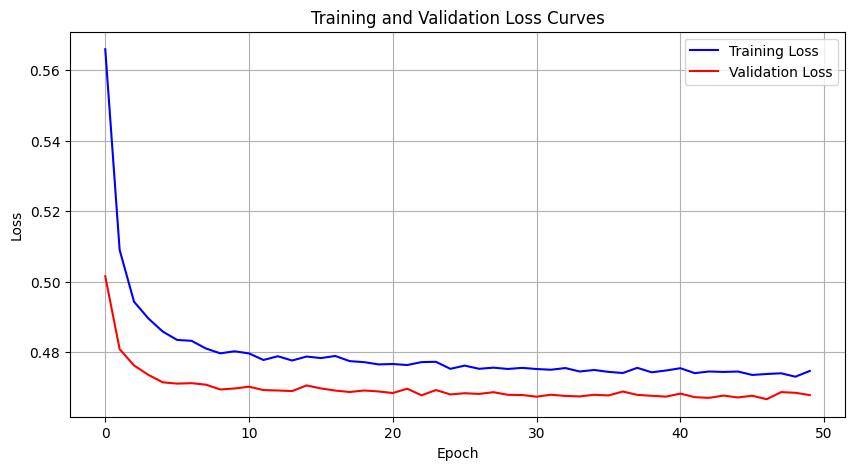

 Loss curves saved to ../results/mlp_improved/loss_curves.png


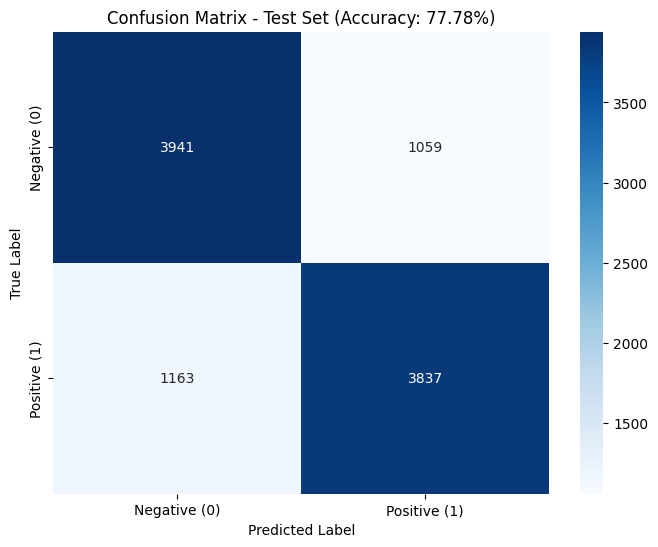

 Confusion matrix saved to ../results/mlp_improved/confusion_matrix.png
 Metrics saved to ../results/mlp_improved/metrics.txt
 Results discussion saved to ../results/mlp_improved/results_discussion.txt
 Submission file saved to ../results/mlp_improved/submission.csv

 ALL DONE! Improved MLP saved correctly!


In [ ]:
# this step is for saving everything
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# saving the model at root level
torch.save(model.state_dict(), '../model/mlp_improved.pth')
print(" Model saved to ../model/mlp_improved.pth")

# plotting and saving loss curves at root level
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.savefig('../results/mlp_improved/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Loss curves saved to ../results/mlp_improved/loss_curves.png")

# creating and saving confusion matrix at root level
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f'Confusion Matrix - Test Set (Accuracy: {test_accuracy:.2%})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('../results/mlp_improved/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved to ../results/mlp_improved/confusion_matrix.png")

# saving metrics
with open('../results/mlp_improved/metrics.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("IMPROVED MLP - EVALUATION METRICS\n")
    f.write("="*50 + "\n\n")
    
    f.write(f"Test Set Accuracy: {test_accuracy:.2%}\n\n")
    
    f.write("Classification Report:\n")
    f.write("-"*30 + "\n")
    f.write(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    
    f.write("\n\nConfusion Matrix:\n")
    f.write("-"*30 + "\n")
    f.write(f"True Negatives: {cm[0,0]}\n")
    f.write(f"False Positives: {cm[0,1]}\n")
    f.write(f"False Negatives: {cm[1,0]}\n")
    f.write(f"True Positives: {cm[1,1]}\n")

print(" Metrics saved to ../results/mlp_improved/metrics.txt")

# results discussion
with open('../results/mlp_improved/results_discussion.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("IMPROVED MLP - RESULTS DISCUSSION\n")
    f.write("="*50 + "\n\n")
    
    f.write(f"Model Performance:\n")
    f.write(f"- Test Accuracy: {test_accuracy:.2%}\n")
    f.write(f"- Training Accuracy (final): {train_accuracies[-1]:.2f}%\n")
    f.write(f"- Validation Accuracy (final): {val_accuracies[-1]:.2f}%\n\n")

print(" Results discussion saved to ../results/mlp_improved/results_discussion.txt")

print("\n" + "="*50)
print(" ALL DONE! Improved MLP saved correctly!")
print("="*50)